In [1]:
import torch 
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
from torchsummary import summary
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
device = 'cuda' if torch.cuda.is_available else 'cpu'

Preprocessing

In [3]:
data_df = pd.read_csv('data/riceClassification.csv')
data_df.dropna(inplace=True)
data_df.drop(columns=['id'], inplace=True)
original_df = data_df.copy()

In [4]:
for column in data_df.columns:
    data_df[column] = data_df[column]/data_df[column].abs().max()

In [5]:
X = np.array(data_df.iloc[:, :-1]) 
y = np.array(data_df.iloc[:, -1])

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

In [7]:
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5)

In [8]:
class dataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).to(device)
        self.y = torch.tensor(y, dtype=torch.float32).to(device)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        return self.X[index], self.y[index]    

In [9]:
training_data = dataset(X_train, y_train)
testing_data = dataset(X_test, y_test)
validation_data = dataset(X_val, y_val)

In [10]:
train_dataloader = DataLoader(training_data, batch_size=8, shuffle=True)
validation_dataloader = DataLoader(training_data, batch_size=8, shuffle=True)
test_dataloader = DataLoader(testing_data, batch_size=8)

Model definition

In [11]:
class ClassificationModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.input_layer = nn.Linear(input_dim, 10)
        self.hidden = nn.ReLU()
        self.output_layer = nn.Linear(10, 1)

    def forward(self, x):
        x = self.input_layer(x)
        x = self.hidden(x)
        x = self.output_layer(x)
        return x    

In [12]:
model = ClassificationModel(X.shape[1]).to(device)

In [13]:
summary(model, (X.shape[1], ))

Layer (type:depth-idx)                   Output Shape              Param #
├─Linear: 1-1                            [-1, 10]                  110
├─ReLU: 1-2                              [-1, 10]                  --
├─Linear: 1-3                            [-1, 1]                   11
Total params: 121
Trainable params: 121
Non-trainable params: 0
Total mult-adds (M): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00


Layer (type:depth-idx)                   Output Shape              Param #
├─Linear: 1-1                            [-1, 10]                  110
├─ReLU: 1-2                              [-1, 10]                  --
├─Linear: 1-3                            [-1, 1]                   11
Total params: 121
Trainable params: 121
Non-trainable params: 0
Total mult-adds (M): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

In [14]:
criterion = nn.BCEWithLogitsLoss()
optimizer = Adam(model.parameters(), lr=0.001)

In [15]:
train_loss_plot = []
val_loss_plot = []
train_acc_plot = []
val_acc_plot = []

Training

In [16]:
epochs = 10

train_loss_plot = []
val_loss_plot = []
train_acc_plot = []
val_acc_plot = []

for epoch in range(epochs):

    train_loss = 0
    train_acc = 0
    val_loss = 0
    val_acc = 0

    model.train()
    for inputs, labels in train_dataloader:

        predictions = model(inputs).squeeze(1)
        batch_loss = criterion(predictions, labels)

        optimizer.zero_grad()
        batch_loss.backward()
        optimizer.step()

        train_loss += batch_loss.item()
        probs = torch.sigmoid(predictions)
        train_acc += (probs.round() == labels).sum().item()

    model.eval()
    with torch.no_grad():
        for inputs, labels in validation_dataloader:

            predictions = model(inputs).squeeze(1)
            batch_loss = criterion(predictions, labels)

            val_loss += batch_loss.item()
            probs = torch.sigmoid(predictions)
            val_acc += (probs.round() == labels).sum().item()

    train_loss /= len(train_dataloader)
    val_loss /= len(validation_dataloader)

    train_acc /= len(train_dataloader.dataset)
    val_acc /= len(validation_dataloader.dataset)

    train_loss_plot.append(train_loss)
    val_loss_plot.append(val_loss)
    train_acc_plot.append(train_acc)
    val_acc_plot.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss {train_loss:.4f} | Val Loss {val_loss:.4f} | Train Acc {train_acc:.4f} | Val Acc {val_acc:.4f}")

Epoch 1/10 | Train Loss 0.4856 | Val Loss 0.2347 | Train Acc 0.8418 | Val Acc 0.9843
Epoch 2/10 | Train Loss 0.1361 | Val Loss 0.0868 | Train Acc 0.9827 | Val Acc 0.9852
Epoch 3/10 | Train Loss 0.0713 | Val Loss 0.0596 | Train Acc 0.9842 | Val Acc 0.9850
Epoch 4/10 | Train Loss 0.0551 | Val Loss 0.0508 | Train Acc 0.9848 | Val Acc 0.9848
Epoch 5/10 | Train Loss 0.0490 | Val Loss 0.0462 | Train Acc 0.9853 | Val Acc 0.9855
Epoch 6/10 | Train Loss 0.0462 | Val Loss 0.0441 | Train Acc 0.9853 | Val Acc 0.9855
Epoch 7/10 | Train Loss 0.0445 | Val Loss 0.0431 | Train Acc 0.9857 | Val Acc 0.9858
Epoch 8/10 | Train Loss 0.0433 | Val Loss 0.0425 | Train Acc 0.9850 | Val Acc 0.9848
Epoch 9/10 | Train Loss 0.0423 | Val Loss 0.0421 | Train Acc 0.9853 | Val Acc 0.9847
Epoch 10/10 | Train Loss 0.0420 | Val Loss 0.0417 | Train Acc 0.9850 | Val Acc 0.9857


Plotting Graphs

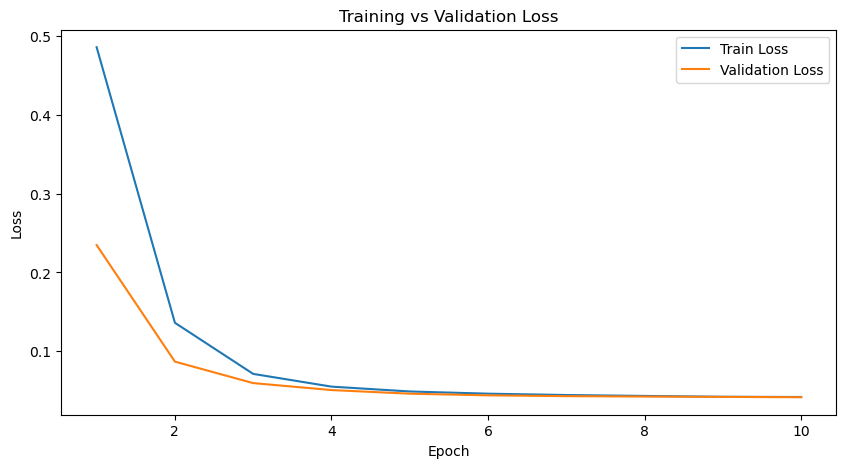

In [17]:
epochs_range = range(1, len(train_loss_plot) + 1)

plt.figure(figsize=(10,5))

plt.plot(epochs_range, train_loss_plot, label="Train Loss")
plt.plot(epochs_range, val_loss_plot, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

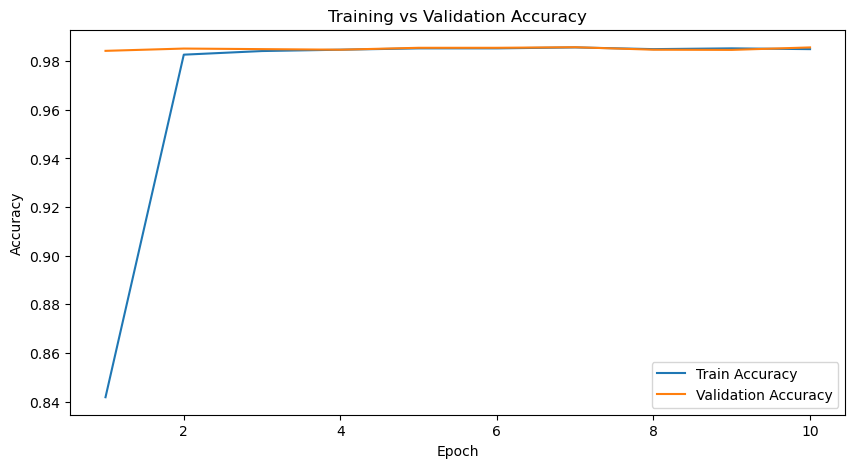

In [18]:
plt.figure(figsize=(10,5))

plt.plot(epochs_range, train_acc_plot, label="Train Accuracy")
plt.plot(epochs_range, val_acc_plot, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

In [19]:
test_loss = 0
test_acc = 0

model.eval()

with torch.no_grad():
    for inputs, labels in test_dataloader:

        inputs = inputs.to(device)
        labels = labels.to(device)

        predictions = model(inputs).squeeze(1)

        loss = criterion(predictions, labels)
        test_loss += loss.item()

        probs = torch.sigmoid(predictions)
        preds = (probs > 0.5).float()

        test_acc += (preds == labels).sum().item()


test_loss /= len(test_dataloader)
test_acc /= len(test_dataloader.dataset)

print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")

Test Loss: 0.0410 | Test Accuracy: 0.9875


In [20]:
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for inputs, labels in test_dataloader:

        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs).squeeze(1)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

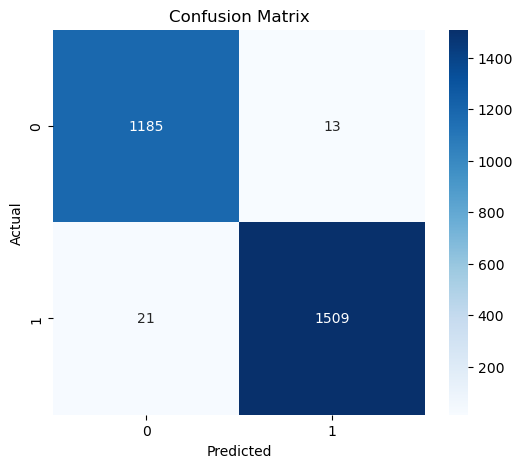

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [22]:
import os

os.makedirs("models", exist_ok=True)
torch.save(model.state_dict(), "models/rice_classifier.pth")